In [35]:
from typing import List, Dict,  Union
from datetime import datetime
import pandas as pd

from ccxt.binance import binance
from ccxt.base.exchange import Exchange

from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_volume_profile, compute_value_area

### Fetch candles

In [36]:
start_date : datetime = datetime(2026,3,1)
end_date : datetime = datetime(2026,3,31)

param = {
    'apiKey' : None,
    'secret' : None,
    'password' : None,
    'subaccount' : None,
    'rateLimit' : 100,    # In ms
    'options' : {
        'defaultType': 'swap'            }
}

exchange : Exchange = binance(param) # type: ignore
normalized_symbols = [ 'SOL/USDT:USDT' ]
pd_candles: Union[pd.DataFrame, None] = fetch_candles(
    start_ts=start_date.timestamp(),
    end_ts=end_date.timestamp(),
    exchange=exchange,
    normalized_symbols=normalized_symbols,
    candle_size='15m'
)[normalized_symbols[0]]

assert pd_candles is not None

### Volume Profile

In [37]:
volume_profile = compute_volume_profile(
            pd_candles = pd_candles,
            level_granularity = 0.1, # i.e. 10%
            ohlc = 'close' # Compute volume profile from 'close' prices? Permissible values: open, high, low, close
        )
for x in volume_profile:
    bucket_key = x['bucket_key']
    volume = x['volume']
    local_maxima = x['local_maxima']
    if local_maxima:
        point_of_control = f'{bucket_key} volume: {int(volume):,}'
        print(point_of_control)

86.0 - 88.0 volume: 130,734,502


In [38]:
va = compute_value_area(volume_profile, value_area_pct=0.70)
va

{'vah': 90.0,
 'val': 82.0,
 'va_mid': '86.0 - 88.0',
 'vah_bucket': '88.0 - 90.0',
 'val_bucket': '82.0 - 84.0'}

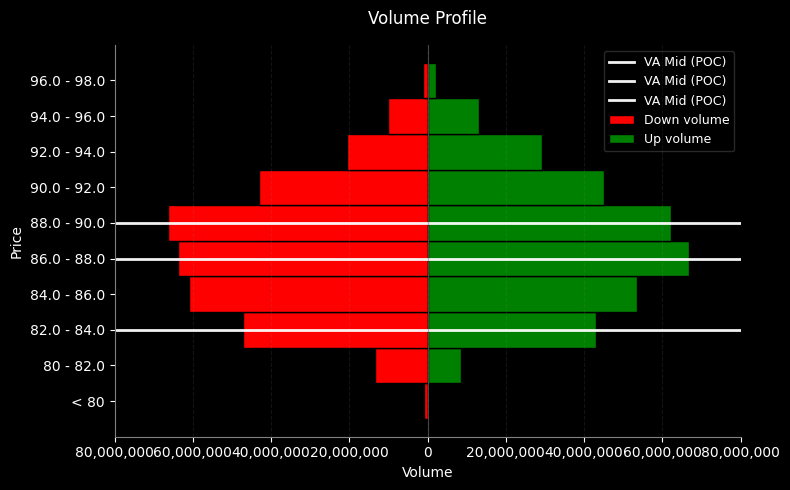

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('dark_background')

bins = list(reversed([x['bucket_key'] for x in volume_profile]))
up_volumes = list(reversed([x['up_volume'] for x in volume_profile]))
down_volumes = list(reversed([x['down_volume'] for x in volume_profile]))

bins = bins[::-1]
up_volumes = up_volumes[::-1]
down_volumes = down_volumes[::-1]

plt.figure(figsize=(8, len(bins) * 0.5))

ax = plt.gca()

# down_volumes
ax.barh(
    y=bins,
    width=[-v for v in down_volumes],
    color='red',
    edgecolor='black',
    height=1,
    align='center',
    label='Down volume'
)

# up_volumes
ax.barh(
    y=bins,
    width=up_volumes,
    color='green',
    edgecolor='black',
    height=1,
    align='center',
    label='Up volume'
)

# Value Area
ax.axhline(y=va['vah_bucket'], color='white', linestyle='-', linewidth=2.0, alpha=0.95, label='VA Mid (POC)')
ax.axhline(y=va['va_mid'], color='white', linestyle='-', linewidth=2.0, alpha=0.95, label='VA Mid (POC)')
ax.axhline(y=va['val_bucket'], color='white', linestyle='-', linewidth=2.0, alpha=0.95, label='VA Mid (POC)')

ax.set_xlabel('Volume', color='white')
ax.set_ylabel('Price', color='white')
ax.set_title('Volume Profile', color='white', pad=15)

ax.xaxis.set_tick_params(labelcolor='white')
ax.yaxis.set_tick_params(labelcolor='white')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([f'{int(abs(x)):,}' for x in ax.get_xticks()], color='white')

ax.grid(axis='x', alpha=0.15, linestyle='--', color='gray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')

ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)

ax.legend(loc='upper right', fontsize=9, framealpha=0.2)

plt.tight_layout()
plt.show()